# Clasificación de Imágenes con MobileNet

## Objetivos del ejercicio:
- Entender qué es un modelo pre-entrenado
- Usar MobileNetV2 para clasificar imágenes
- Ver cómo funciona Transfer Learning
- Probar con imágenes divertidas y reales

---

## ¿Qué es MobileNet?
- Modelo de clasificación de imágenes creado por Google
- Entrenado con **ImageNet** (dataset de imágenes)
- Optimizado para dispositivos móviles (ligero y rápido)
- **No necesitamos entrenarlo**, ya está listo para usar ✨

## Paso 1: Instalar y cargar librerías

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

print(f"TensorFlow version: {tf.__version__}")
print("Librerías cargadas correctamente")

TensorFlow version: 2.20.0
Librerías cargadas correctamente


## Paso 2: Cargar el modelo MobileNetV2 pre-entrenado

Este paso descarga el modelo (solo la primera vez). El modelo pesa ~14 MB.

In [2]:
print("Cargando modelo MobileNetV2...")
model = MobileNetV2(weights='imagenet')
print("Modelo cargado exitosamente!")

Cargando modelo MobileNetV2...
Modelo cargado exitosamente!


## Paso 3: Crear funciones auxiliares

Estas funciones nos ayudarán a:
1. Cargar imágenes desde URL o archivo local
2. Preprocesar la imagen para el modelo
3. Hacer predicciones y mostrar resultados

In [20]:
def cargar_imagen_desde_url(url):
    """Descarga una imagen desde una URL"""
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    return img

def cargar_imagen_local(ruta):
    """Carga una imagen desde el disco local"""
    img = Image.open(ruta)
    return img

def preprocesar_imagen(img):
    """Preprocesa la imagen para MobileNetV2"""
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img = img.resize((224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

def predecir_y_mostrar(img, titulo="Imagen"):
    """Hace la predicción y muestra la imagen con los resultados"""
    img_procesada = preprocesar_imagen(img)
    
    print(f"\n{'='*60}")
    print(f"Analizando: {titulo}")
    print(f"{'='*60}")
    
    predicciones = model.predict(img_procesada, verbose=0)
    resultados = decode_predictions(predicciones, top=5)[0]
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(titulo, fontsize=14, fontweight='bold')
    
    plt.subplot(1, 2, 2)
    categorias = [resultado[1].replace('_', ' ').title() for resultado in resultados]
    confianzas = [resultado[2] * 100 for resultado in resultados]
    
    colores = ['#2ecc71' if i == 0 else '#3498db' for i in range(5)]
    bars = plt.barh(categorias, confianzas, color=colores)
    plt.xlabel('Confianza (%)', fontsize=12)
    plt.title('Top 5 Predicciones', fontsize=14, fontweight='bold')
    plt.xlim(0, 100)
    
    for i, (bar, conf) in enumerate(zip(bars, confianzas)):
        plt.text(conf + 1, bar.get_y() + bar.get_height()/2, 
                f'{conf:.1f}%', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPredicción principal: {resultados[0][1].replace('_', ' ').upper()}")
    print(f"Confianza: {resultados[0][2]*100:.2f}%")
    print(f"\nTop 5 predicciones:")
    for i, (id_clase, nombre, confianza) in enumerate(resultados, 1):
        print(f"   {i}. {nombre.replace('_', ' ').title()}: {confianza*100:.2f}%")

print("✅ Funciones creadas correctamente")

✅ Funciones creadas correctamente


## Paso 4: ¡Probemos el modelo!

### Ejemplo 1: Un perro Golden Retriever


Analizando: Golden Retriever
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


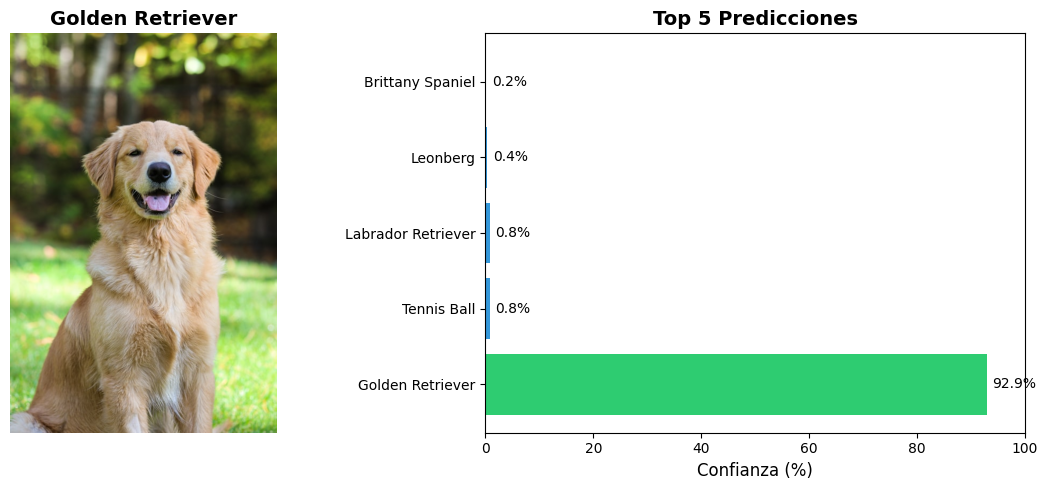


Predicción principal: GOLDEN RETRIEVER
Confianza: 92.93%

Top 5 predicciones:
   1. Golden Retriever: 92.93%
   2. Tennis Ball: 0.82%
   3. Labrador Retriever: 0.81%
   4. Leonberg: 0.39%
   5. Brittany Spaniel: 0.19%


In [4]:
url_perro = "https://images.unsplash.com/photo-1633722715463-d30f4f325e24?w=500"
img_perro = cargar_imagen_desde_url(url_perro)
predecir_y_mostrar(img_perro, "Golden Retriever")

### Ejemplo 2: Un gato


Analizando: Gato


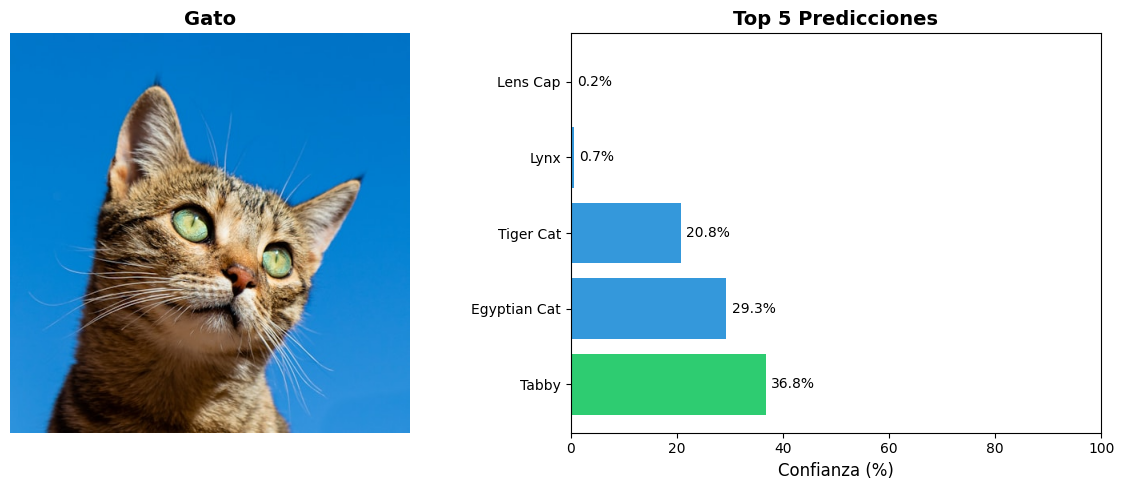


Predicción principal: TABBY
Confianza: 36.82%

Top 5 predicciones:
   1. Tabby: 36.82%
   2. Egyptian Cat: 29.33%
   3. Tiger Cat: 20.82%
   4. Lynx: 0.67%
   5. Lens Cap: 0.22%


In [5]:
url_gato = "https://images.unsplash.com/photo-1574158622682-e40e69881006?w=500"
img_gato = cargar_imagen_desde_url(url_gato)
predecir_y_mostrar(img_gato, "Gato")

### Ejemplo 3: Una pizza


Analizando: Pizza


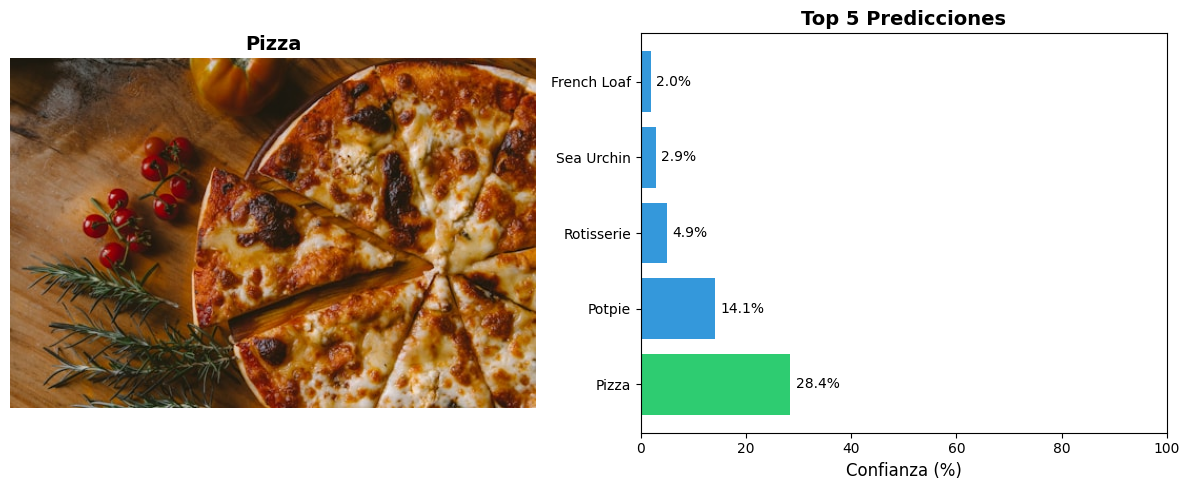


Predicción principal: PIZZA
Confianza: 28.44%

Top 5 predicciones:
   1. Pizza: 28.44%
   2. Potpie: 14.13%
   3. Rotisserie: 4.92%
   4. Sea Urchin: 2.87%
   5. French Loaf: 1.96%


In [6]:
url_pizza = "https://images.unsplash.com/photo-1513104890138-7c749659a591?w=500"
img_pizza = cargar_imagen_desde_url(url_pizza)
predecir_y_mostrar(img_pizza, "Pizza")

### Ejemplo 4: Un coche deportivo


Analizando: Coche Deportivo


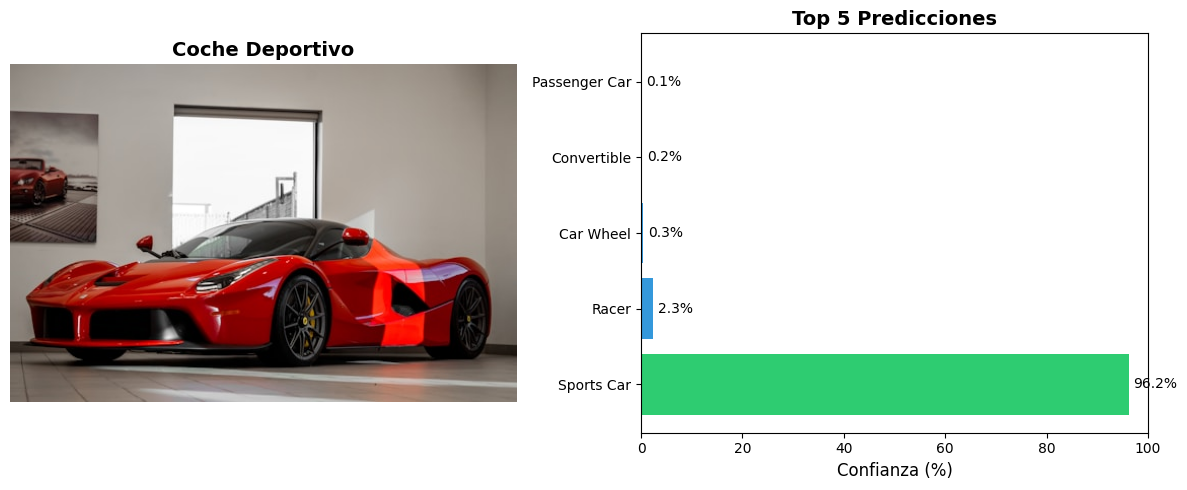


Predicción principal: SPORTS CAR
Confianza: 96.17%

Top 5 predicciones:
   1. Sports Car: 96.17%
   2. Racer: 2.28%
   3. Car Wheel: 0.30%
   4. Convertible: 0.18%
   5. Passenger Car: 0.05%


In [7]:
url_coche = "https://images.unsplash.com/photo-1583121274602-3e2820c69888?w=500"
img_coche = cargar_imagen_desde_url(url_coche)
predecir_y_mostrar(img_coche, "Coche Deportivo")

### Ejemplo 5: Un avión


Analizando: Avión


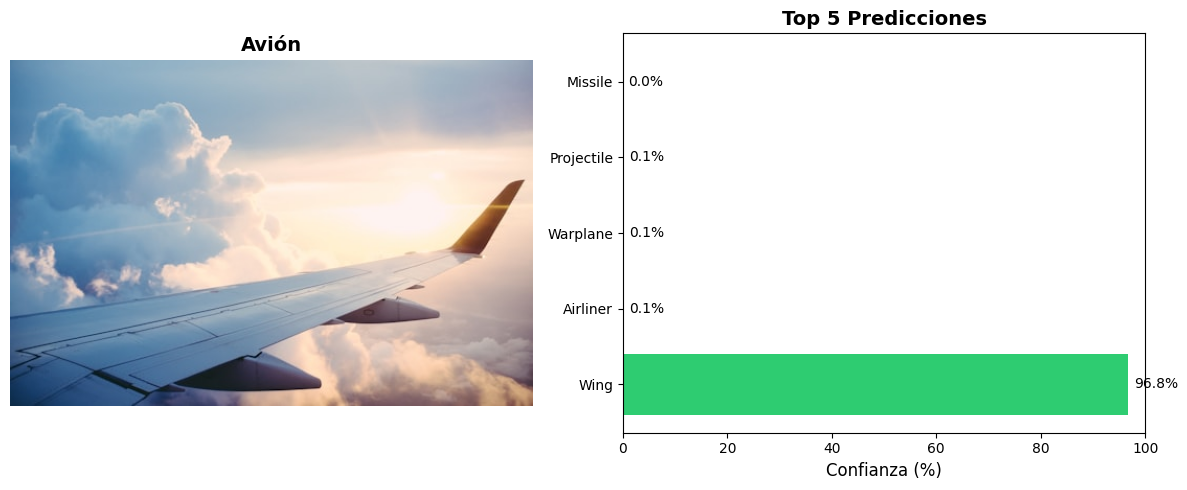


Predicción principal: WING
Confianza: 96.79%

Top 5 predicciones:
   1. Wing: 96.79%
   2. Airliner: 0.15%
   3. Warplane: 0.15%
   4. Projectile: 0.12%
   5. Missile: 0.04%


In [8]:
url_avion = "https://images.unsplash.com/photo-1436491865332-7a61a109cc05?w=500"
img_avion = cargar_imagen_desde_url(url_avion)
predecir_y_mostrar(img_avion, "Avión")

### Ejemplo 6: Una taza de café


Analizando: Café


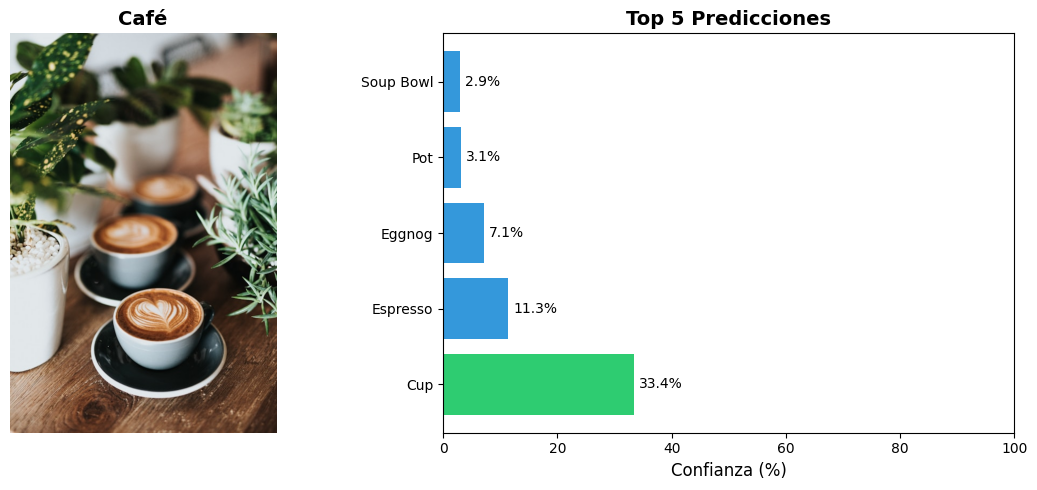


Predicción principal: CUP
Confianza: 33.37%

Top 5 predicciones:
   1. Cup: 33.37%
   2. Espresso: 11.31%
   3. Eggnog: 7.08%
   4. Pot: 3.07%
   5. Soup Bowl: 2.91%


In [9]:
url_cafe = "https://images.unsplash.com/photo-1509042239860-f550ce710b93?w=500"
img_cafe = cargar_imagen_desde_url(url_cafe)
predecir_y_mostrar(img_cafe, "Café")

### Ejemplo 7: Un elefante


Analizando: Elefante


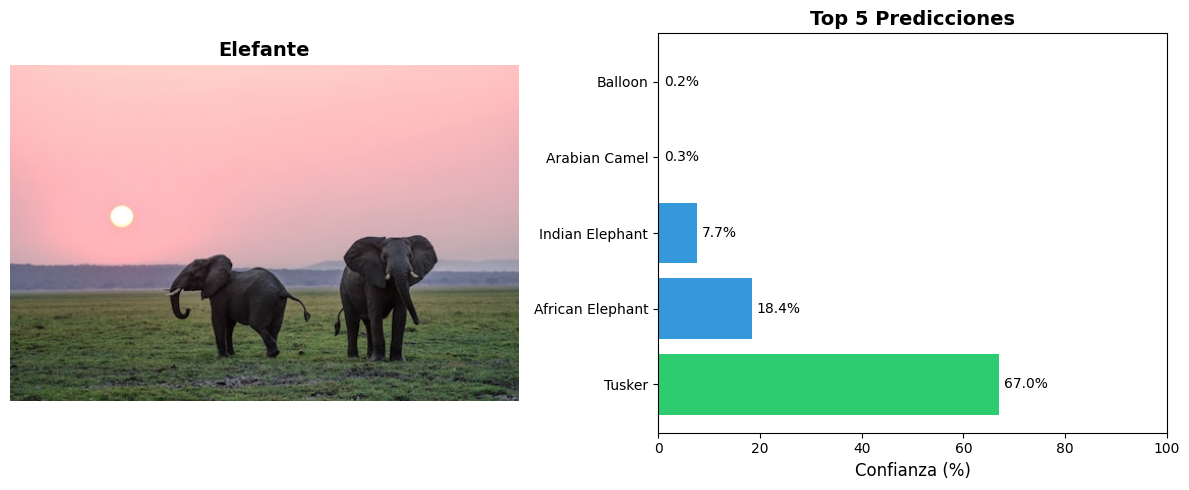


Predicción principal: TUSKER
Confianza: 66.99%

Top 5 predicciones:
   1. Tusker: 66.99%
   2. African Elephant: 18.41%
   3. Indian Elephant: 7.68%
   4. Arabian Camel: 0.26%
   5. Balloon: 0.15%


In [10]:
url_elefante = "https://images.unsplash.com/photo-1564760055775-d63b17a55c44?w=500"
img_elefante = cargar_imagen_desde_url(url_elefante)
predecir_y_mostrar(img_elefante, "Elefante")

### Ejemplo 8: Una guitarra


Analizando: Guitarra


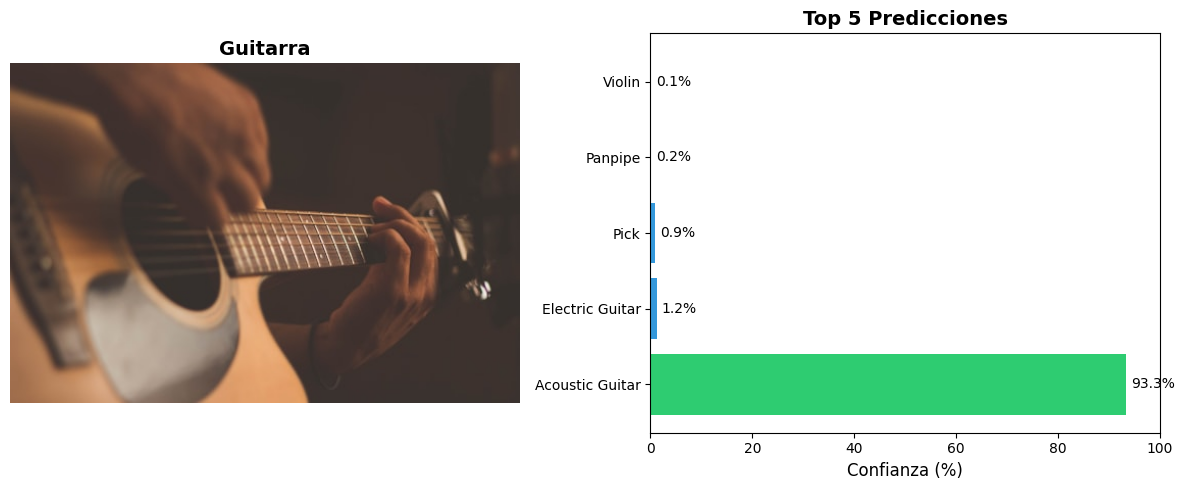


Predicción principal: ACOUSTIC GUITAR
Confianza: 93.33%

Top 5 predicciones:
   1. Acoustic Guitar: 93.33%
   2. Electric Guitar: 1.21%
   3. Pick: 0.86%
   4. Panpipe: 0.20%
   5. Violin: 0.09%


In [11]:
url_guitarra = "https://images.unsplash.com/photo-1510915361894-db8b60106cb1?w=500"
img_guitarra = cargar_imagen_desde_url(url_guitarra)
predecir_y_mostrar(img_guitarra, "Guitarra")

### Ejemplo 9: Imagen fuera de categorías - Código QR

**Experimento**: ¿Qué pasa cuando le damos al modelo algo que NO está en sus 1000 categorías de entrenamiento?

Los códigos QR no existen en ImageNet. Veamos cómo intenta clasificarlo el modelo.


Analizando: Código QR (NO en ImageNet)


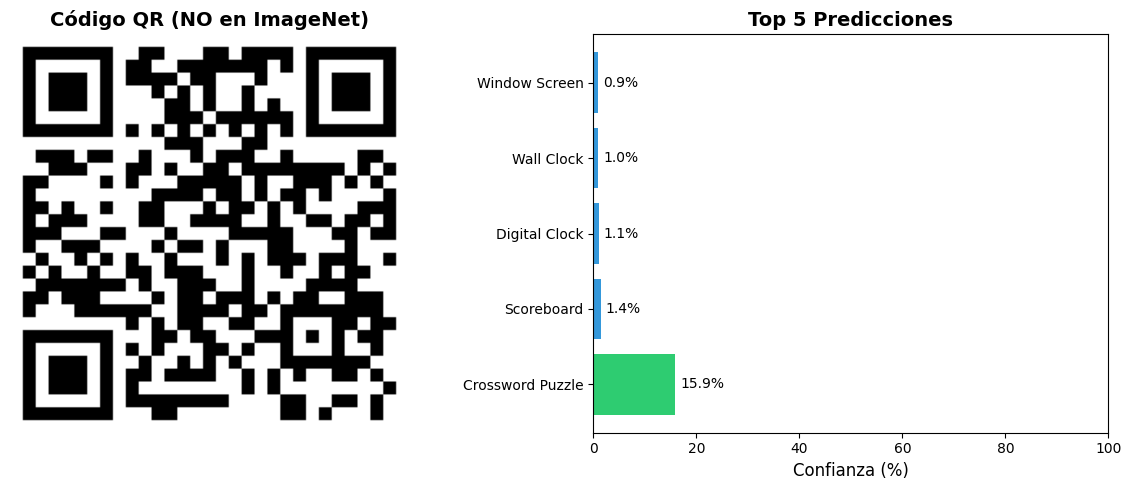


Predicción principal: CROSSWORD PUZZLE
Confianza: 15.91%

Top 5 predicciones:
   1. Crossword Puzzle: 15.91%
   2. Scoreboard: 1.41%
   3. Digital Clock: 1.06%
   4. Wall Clock: 1.01%
   5. Window Screen: 0.94%


In [21]:
url_qr = "images/QR.png"
img_qr = cargar_imagen_local(url_qr)
predecir_y_mostrar(img_qr, "Código QR (NO en ImageNet)")

### 📊 Evaluación del resultado

**¿Qué observamos?**

Cuando el modelo recibe una imagen que **no está en sus categorías de entrenamiento**, intenta forzar una clasificación usando las 1000 categorías que conoce. Esto resulta en:

1. **Predicciones incorrectas**: El modelo asigna la imagen a la categoría más "parecida" visualmente
2. **Baja confianza**: Los porcentajes suelen ser más bajos (20-40%) comparado con imágenes correctas (80-99%)
3. **Predicciones dispersas**: Las top 5 predicciones tienen valores similares, sin un claro ganador

**Lecciones importantes:**

- ✅ El modelo **solo puede clasificar lo que aprendió** durante el entrenamiento
- ⚠️ **No dice "no sé"** - siempre da una respuesta, aunque sea incorrecta
- 🎯 Para objetos nuevos necesitarías **re-entrenar o hacer transfer learning**
- 🔍 La **confianza baja** es una señal de que el modelo está "adivinando"

**Aplicación práctica:**

En producción, podrías establecer un **umbral de confianza** (ej: 50%) y rechazar predicciones por debajo de ese valor con un mensaje: "No puedo clasificar esta imagen con certeza".

## Ejercicio

### Opción 1: Probar con una URL de internet

In [ ]:
mi_url = "PEGA_AQUI_TU_URL"
mi_imagen = cargar_imagen_desde_url(mi_url)
predecir_y_mostrar(mi_imagen, "Mi imagen")

### Opción 2: Probar con una imagen local

Sube tu imagen a la carpeta `imagenes/` y cambia el nombre del archivo:

In [ ]:
ruta_local = "imagenes/mi_foto.jpg"
mi_imagen_local = cargar_imagen_local(ruta_local)
predecir_y_mostrar(mi_imagen_local, "Mi foto")

## Reflexiones y discusión

### Preguntas para pensar:

1. **¿El modelo siempre acierta?** ¿Qué pasa si le damos una imagen ambigua?

2. **¿Qué significa la confianza?** ¿Por qué a veces es 99% y otras veces 30%?

3. **Limitaciones**: ¿Qué pasa si le damos una imagen que no está en las 1000 categorías de ImageNet?

4. **Aplicaciones reales**: ¿Dónde podríamos usar este modelo?
   - Organizar fotos automáticamente
   - Búsqueda visual en e-commerce
   - Accesibilidad (describir imágenes para personas con discapacidad visual)
   - Control de calidad en fábricas

5. **Ética**: ¿Qué problemas éticos pueden surgir al usar modelos de clasificación de imágenes?

## Conceptos clave aprendidos

**Transfer Learning**: Usar un modelo pre-entrenado sin necesidad de entrenarlo desde cero

**ImageNet**: Dataset masivo usado para entrenar modelos de visión por computadora

**Preprocesamiento**: Las imágenes deben transformarse al formato que el modelo espera (224x224 píxeles)

**Confianza**: El modelo da probabilidades, no certezas absolutas

**Top-K predicciones**: Es útil ver las mejores 5 predicciones, no solo la primera

---

## Recursos adicionales

- [TensorFlow Hub](https://tfhub.dev/)
- [Hugging Face Models](https://huggingface.co/models)
- [ImageNet Categories](https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/)
- [Papers with Code - Computer Vision](https://paperswithcode.com/area/computer-vision)

---

### Tip final

**¡Experimenta!** Prueba con diferentes imágenes y observa:
- ¿Cuándo el modelo se confunde?
- ¿Qué categorías son similares entre sí?
- ¿Cómo afecta la calidad de la imagen a las predicciones?